In [1]:
import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import (
    plot_biomarker_trajectories,
    plot_true_observations,
    plot_initial_beta_guess,
    plot_theta_fit_comparison,
    plot_theta_error_history,
    plot_beta_overlay,
    plot_beta_error_history,
    plot_lse,
    plot_cog_regression_history
)
from EMDPM.utils import solve_system, initialize_f_eigen
from EMDPM.em_transformer_rework import EM


true x0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
true f: [0.         0.01123988 0.01207819 0.01155182 0.02688619 0.
 0.01019029 0.         0.         0.        ]
a = 1.8531667261047913, b = 1.5312904682995265


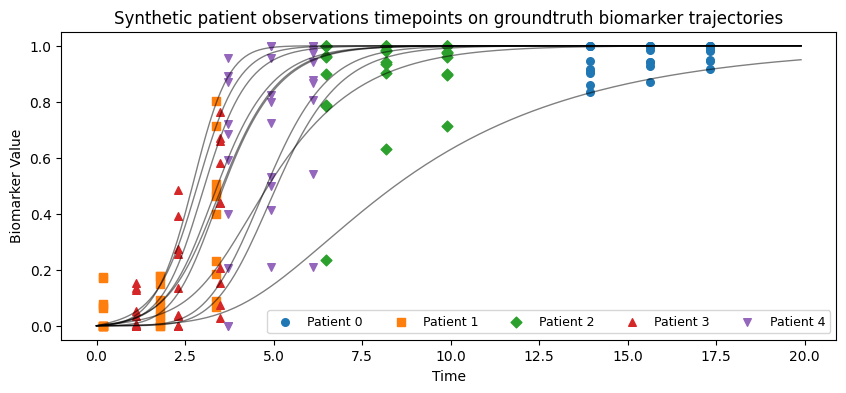

In [2]:
# params
n_biomarkers = 10
t_max = 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.1
n_patients = 200
n_patient_obs = 3


# fit and transform
t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers=n_biomarkers, t_max=t_max)

df, cog_a, cog_b = generate_synthetic_data(
    n_biomarkers = n_biomarkers,
    t_max = t_max, 
    noise_level = noise_level,
    n_patients = n_patients,
    n_patient_obs = n_patient_obs,
    x_true=x_true, 
    t=t,
)
#plot_biomarker_trajectories(t, x_true, n_biomarkers=n_biomarkers)
plot_true_observations(df, t, x_true)

biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

X_obs = df[biomarker_cols].values       # (n_obs, n_biomarkers)
dt = df["dt"].values                # (n_obs,)
ids = df["patient_id"].values       # (n_obs,)
cog = df["cognitive_score"].values  # (n_obs,)
beta_true = df["beta_true"].values 

# print(X.shape, dt.shape, ids.shape, cog.shape, beta_true.shape)

def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
#X_train, X_val = train_test_split(X, test_size=0.2, random_state=75)

#print(X[0])

In [3]:
f_inits = initialize_f_eigen(K=K, jitter_strength=0.05, n_eigs=3, rng=np.random.RandomState(75))
print(f_inits[0])

[0.         0.05475099 0.20546771 0.33808425 0.51194772 0.57762083
 0.46532192 0.24716525 0.1129469  0.12436326]


In [ ]:
from joblib import Parallel, delayed
from scipy.stats import spearmanr, kendalltau, pearsonr

def fit_em_for_f_init(
    K,
    patients,
    f_init_vec,
    em_kwargs,
    run_index,
    seed_offset=0
):
    """
    Make a fresh EM, set initial_f, fit it, and return a dict of results.
    Designed to be called in parallel.
    """
    rng = np.random.default_rng(75 + seed_offset + run_index)

    em = EM(
        K=K,
        max_iter=em_kwargs.get("max_iter", 30),
        t_max=em_kwargs.get("t_max", 20),
        step=em_kwargs.get("step", 0.01),
        jac_toggle=em_kwargs.get("jac_toggle", True),
        lambda_f=em_kwargs.get("lambda_f", 0.5),
        lambda_cog=em_kwargs.get("lambda_cog", 0.0),
        lambda_scalar=em_kwargs.get("lambda_scalar", 0.1),
        epsilon=em_kwargs.get("epsilon", 1e-4),
        verbose=em_kwargs.get("verbose", 1),
        rng=rng
    )

    em.initial_f = np.array(f_init_vec, dtype=float)  # supply init f
    em.fit(X=patients, y=None)

    n_biomarkers = patients[0]["X_obs"].shape[1]
    theta_history = em.theta_history
    lse_history = em.lse_history

    final_theta = theta_history[:, -1]
    final_f = final_theta[:n_biomarkers]
    final_s = final_theta[n_biomarkers:2*n_biomarkers]
    final_scalar_K = float(final_theta[-1])

    initial_theta = theta_history[:, 0]
    initial_f = initial_theta[:n_biomarkers]
    initial_s = initial_theta[n_biomarkers:2*n_biomarkers]
    initial_scalar_K = float(initial_theta[-1])

    initial_lse = float(lse_history[0])
    final_lse = float(lse_history[-1])
    relative_improvement = (initial_lse - final_lse) / initial_lse if initial_lse > 0 else np.nan

    result = {
        "run_index": run_index,
        "model": em,
        "theta_history": theta_history,
        "beta_history": em.beta_history,
        "lse_history": lse_history,
        "initial_f": initial_f,
        "initial_s": initial_s,
        "initial_scalar_K": initial_scalar_K,
        "final_f": final_f,
        "final_s": final_s,
        "final_scalar_K": final_scalar_K,
        "initial_lse": initial_lse,
        "final_lse": final_lse,
        "relative_improvement": relative_improvement,
    }
    return result

def run_multi_inits_parallel(
    K,
    patients,
    f_candidates,
    em_kwargs,
    n_jobs=-1,
    prefer="processes",
    truth_dict=None
):
    """
    Run one EM fit per f in f_candidates, in parallel.
    Returns (results_list, best_index). Best is by lowest final LSE.
    """
    jobs = []
    for idx, f_vec in enumerate(f_candidates):
        jobs.append(delayed(fit_em_for_f_init)(
            K, patients, f_vec, em_kwargs, run_index=idx
        ))

    results = Parallel(n_jobs=n_jobs, prefer=prefer)(jobs)

    # correlations vs truth if provided
    if truth_dict is not None:
        f_true = truth_dict.get("f_true", None)
        if f_true is not None:
            for res in results:
                rho, _ = spearmanr(f_true, res["final_f"])
                tau, _ = kendalltau(f_true, res["final_f"])
                res["spearman_f"] = float(rho)
                res["kendall_f"] = float(tau)
        else:
            for res in results:
                res["spearman_f"] = np.nan
                res["kendall_f"]  = np.nan

    # pick best by lowest final LSE
    best_index = min(range(len(results)), key=lambda i: results[i]["final_lse"])
    return results, best_index

In [6]:
def create_f_init(
    n_biomarkers: int,
    n_inits: int,
    rng: np.random.RandomState,
    intensity_range: tuple[float, float] = (0.0, 0.2),
    sparsity_range: tuple[float, float] | None = None,
) -> list[np.ndarray]:
    """
    Create a list of f-initializations by drawing values within ranges.

    Parameters
    ----------
    n_biomarkers : int
        Length of f vector.
    n_inits : int
        Number of initializations to generate.
    rng : np.random.Generator | None
        Random generator. If None, uses default_rng(75).
    intensity_range : (low, high)
        Range for uniform draw of nonzero entries.
    sparsity_range : (low, high) or None
        keep values between 0 and 1

    Returns
    -------
    list of np.ndarray
        Candidate f vectors.
    """
    if rng is None:
        rng = np.random.RandomState(75)

    f_inits: list[np.ndarray] = []

    for init_idx in range(n_inits):
        # draw intensity range upper bound if specified
        upper = intensity_range[1]
        lower = intensity_range[0]
        f_vec = rng.uniform(lower, upper, size=n_biomarkers)

        # apply sparsity mask if specified
        if sparsity_range is not None:
            sparsity_here = float(rng.uniform(sparsity_range[0], sparsity_range[1]))
            mask = rng.random(n_biomarkers) > sparsity_here
            f_vec = f_vec * mask.astype(float)

        f_inits.append(f_vec.astype(float))

    return f_inits

f_candidates = create_f_init(n_biomarkers=n_biomarkers,
                             n_inits = 9,
                             rng = np.random.RandomState(75),
                             intensity_range=(0.05,2.0),
                             sparsity_range=(0.0,0.0))

f_candidates.append(np.zeros(n_biomarkers))

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_lse_histories(results, title="LSE histories (all runs)"):
    plt.figure(figsize=(8, 5))
    for i in range(len(results)):
        lse = results[i]["lse_history"]
        label = "run " + str(i)
        plt.plot(lse, label=label)
    plt.xlabel("EM iteration")
    plt.ylabel("LSE")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.show()

def plot_multi_init_errors(
    results,
    f_true=None,
    s_true=None,
    scalar_K_true=None,
    beta_true=None,
    title="Parameter errors by initialization"
):
    colors = plt.get_cmap("tab10")
    if len(results) > 10:
        colors = plt.get_cmap("tab20")

    f_errors, s_errors, scalar_errors, beta_errors = [], [], [], []
    for i in range(len(results)):
        # f error
        if f_true is not None:
            diff = results[i]["final_f"] - f_true
            f_err = float(np.linalg.norm(diff))
        else:
            f_err = np.nan
        f_errors.append(f_err)

        # s error
        if s_true is not None and "final_s" in results[i]:
            s_vec = results[i]["final_s"]
            if s_vec is None or s_vec.size == 0:
                s_err = np.nan
            else:
                diff = s_vec - s_true
                s_err = float(np.linalg.norm(diff))
        else:
            s_err = np.nan
        s_errors.append(s_err)

        # scalar_K error
        if scalar_K_true is not None:
            scalar_err = float(abs(results[i]["final_scalar_K"] - scalar_K_true))
        else:
            scalar_err = np.nan
        scalar_errors.append(scalar_err)

        # beta MSE (optional)
        if beta_true is not None and "beta_history" in results[i]:
            beta_est = results[i]["model"].beta_history[:, -1]
            if beta_true.shape[0] == beta_est.shape[0]:
                beta_err = float(np.mean((beta_est - beta_true) ** 2))
            else:
                beta_err = np.nan
        else:
            beta_err = np.nan
        beta_errors.append(beta_err)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    ax = axes[0, 0]
    for i in range(len(results)):
        ax.bar(i, f_errors[i], color=colors(i % 10))
    ax.set_title("|f_final - f_true|^2"); ax.set_xlabel("run"); ax.set_ylabel("error")

    ax = axes[0, 1]
    for i in range(len(results)):
        ax.bar(i, s_errors[i], color=colors(i % 10))
    ax.set_title("|s_final - s_true|^2"); ax.set_xlabel("run"); ax.set_ylabel("error")

    ax = axes[1, 0]
    for i in range(len(results)):
        ax.bar(i, scalar_errors[i], color=colors(i % 10))
    ax.set_title("|scalar_K_final - scalar_K_true|"); ax.set_xlabel("run"); ax.set_ylabel("abs error")

    ax = axes[1, 1]
    for i in range(len(results)):
        ax.bar(i, beta_errors[i], color=colors(i % 10))
    ax.set_title("beta"); ax.set_xlabel(" "); ax.set_ylabel(" ")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [8]:
def summarize_multi_init_results(results, f_true=None):
    rows = []
    for i in range(len(results)):
        res = results[i]

        # basics
        run_index = res["run_index"]
        initial_lse = float(res["initial_lse"])
        final_lse = float(res["final_lse"])
        relative_improvement = float(res["relative_improvement"])

        # f stats
        fin_f = np.asarray(res["final_f"], dtype=float)
        ini_f = np.asarray(res["initial_f"], dtype=float)

        # zeros and maxima
        pct_zeros_initial = float(np.mean(ini_f == 0.0)) * 100.0
        pct_zeros_final   = float(np.mean(fin_f == 0.0)) * 100.0
        max_initial_f     = float(np.max(ini_f)) if ini_f.size > 0 else np.nan
        max_final_f       = float(np.max(fin_f)) if fin_f.size > 0 else np.nan

        # correlations (only computed if f_true provided)
        if f_true is not None and fin_f.size == len(f_true):
            rho_s, _ = spearmanr(f_true, fin_f)
            tau_k, _ = kendalltau(f_true, fin_f)
            r_p,   _ = pearsonr(f_true, fin_f)
            spearman_val = float(rho_s)
            kendall_val  = float(tau_k)
            pearson_val  = float(r_p)
        else:
            spearman_val = np.nan
            kendall_val  = np.nan
            pearson_val  = np.nan

        row = {
            "run_index": run_index,
            "initial_lse": initial_lse,
            "final_lse": final_lse,
            "relative_improvement": relative_improvement,
            "spearman_f": spearman_val,
            "kendall_f": kendall_val,
            "pearson_f": pearson_val,
            "pct_zeros_initial_f": pct_zeros_initial,
            "pct_zeros_final_f": pct_zeros_final,
            "max_initial_f": max_initial_f,
            "max_final_f": max_final_f,
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    # skim winners
    df["rank_final_lse"] = df["final_lse"].rank(method="min", ascending=True).astype(int)
    df["rank_improvement"] = (-df["relative_improvement"]).rank(method="min", ascending=True).astype(int)
    return df


def plot_f_error_histories_normalized(results, f_true=None, eps=1e-8):
    plt.figure(figsize=(8,5))
    for res in results:
        theta_hist = res["theta_history"]
        n_biomarkers = res["final_f"].shape[0]
        iters = theta_hist.shape[1]

        errors = []
        if f_true is not None:
            for t in range(iters):
                f_t = theta_hist[0:n_biomarkers, t]
                err = float(np.linalg.norm(f_t - f_true))
                errors.append(err)
        else:
            f_final = theta_hist[0:n_biomarkers, -1]
            for t in range(iters):
                f_t = theta_hist[0:n_biomarkers, t]
                err = float(np.linalg.norm(f_t - f_final))
                errors.append(err)

        # normalize to [0,1]
        min_val, max_val = np.min(errors), np.max(errors)
        if max_val > min_val:
            errors_norm = [(e - min_val) / (max_val - min_val + eps) for e in errors]
        else:
            errors_norm = errors

        plt.plot(errors_norm, alpha=0.9)

    plt.xlabel("COMIND iteration")
    plt.ylabel("normalized f-error [0-1]")
    plt.title("normalized f-error histories")
    plt.grid(alpha=0.3)
    plt.show()

def plot_f_error_histories_raw(results, f_true=None):
    plt.figure(figsize=(8,5))
    for res in results:
        theta_hist = res["theta_history"]
        n_biomarkers = res["final_f"].shape[0]
        iters = theta_hist.shape[1]

        errors = []
        if f_true is not None:
            for t in range(iters):
                f_t = theta_hist[0:n_biomarkers, t]
                err = float(np.linalg.norm(f_t - f_true))
                errors.append(err)
        else:
            f_final = theta_hist[0:n_biomarkers, -1]
            for t in range(iters):
                f_t = theta_hist[0:n_biomarkers, t]
                err = float(np.linalg.norm(f_t - f_final))
                errors.append(err)

        plt.plot(errors, alpha=0.9)

    plt.xlabel("EM iteration")
    plt.ylabel("f-error")
    plt.title("f-error histories")
    plt.grid(alpha=0.3)
    plt.show()

def print_final_f_comparison(results, f_true):
    for res in results:
        run_idx = res["run_index"]
        final_f = res["final_f"]
        print(f"\nRun {run_idx}:")
        print("final_f:", np.round(final_f, 4))
        print("true_f: ", np.round(f_true, 4))
        

# 1. get beta_true in the same patient order EM used
def get_beta_true_in_em_order(df, patients):
    beta_true_list = []
    for p in patients:
        pid = p["id"]
        beta_true_val = df.loc[df["patient_id"] == pid, "beta_true"].iloc[0]
        beta_true_list.append(float(beta_true_val))
    return np.array(beta_true_list, dtype=float)

# 2. quick print of final f vs f_true for a run
def print_final_f_vs_true(results, run_index, f_true):
    fin_f = results[run_index]["final_f"]
    print(f"\nRun {run_index} — final f vs true f")
    print("final_f:", np.round(fin_f, 4))
    print("true_f: ", np.round(f_true, 4))


def plot_beta_error_histories_all_runs(results, df, patients, normalize=False, title=None):
    beta_true_vec = get_beta_true_in_em_order(df, patients)

    plt.figure(figsize=(9, 5))
    for res in results:
        beta_hist = res["beta_history"]          # shape: (n_patients, iters+1)
        n_iters = beta_hist.shape[1]
        mae_over_time = []
        for t in range(n_iters):
            beta_est_t = beta_hist[:, t]
            mae = float(np.mean(np.abs(beta_est_t - beta_true_vec)))
            mae_over_time.append(mae)

        if normalize:
            min_val = float(np.min(mae_over_time))
            max_val = float(np.max(mae_over_time))
            denom = max_val - min_val
            if denom > 0:
                mae_over_time = [(v - min_val) / denom for v in mae_over_time]

        label = f"run {res['run_index']}"
        plt.plot(mae_over_time, label=label, alpha=0.9)

    plt.xlabel("iteration")
    plt.ylabel("Mean error")
    if normalize:
        plt.ylabel("Normalized mean |beta| error (0–1)")
    if title is None:
        title = "beta error histories" if normalize else "beta error histories"
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.show()


In [9]:
em_kwargs = {
    "max_iter": 15,
    "t_max": 20,
    "step": 0.01,
    "lambda_f": 0.5,
    "lambda_cog": 0.0,
    "lambda_scalar": 0.1,
    "jac_toggle": True,
    "epsilon": 1e-4,
    "verbose": 1,
}

results, best_idx = run_multi_inits_parallel(
    K=K,
    patients=X,
    f_candidates=f_candidates,
    em_kwargs=em_kwargs,
    n_jobs=10,                    
    prefer="processes",
    truth_dict={"f_true": f}
)

100%|██████████| 15/15 [02:08<00:00,  8.58s/it]


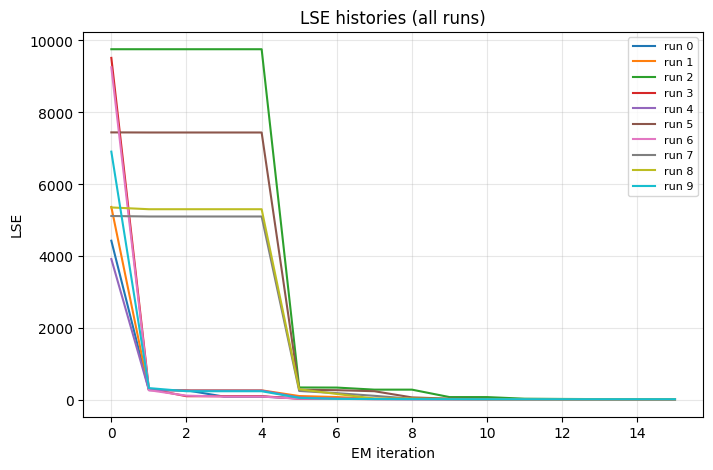

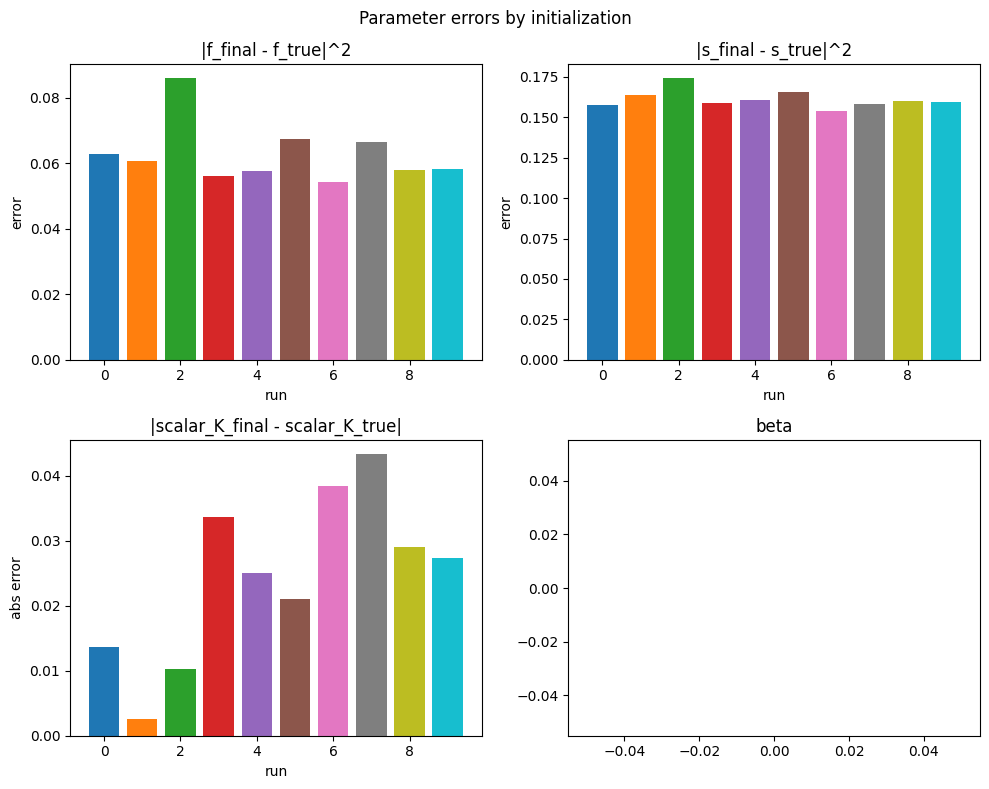

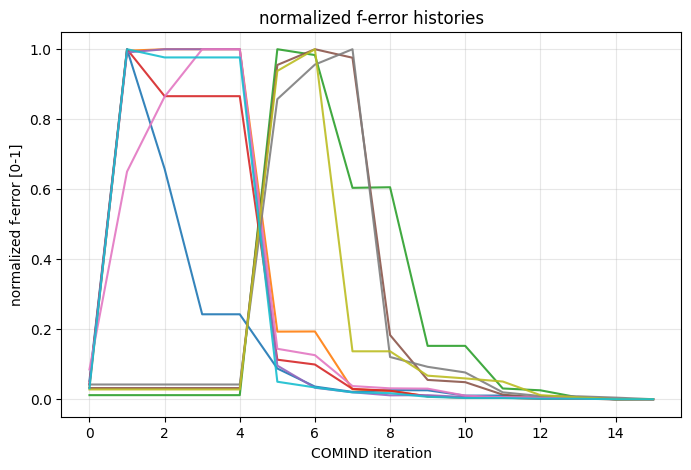

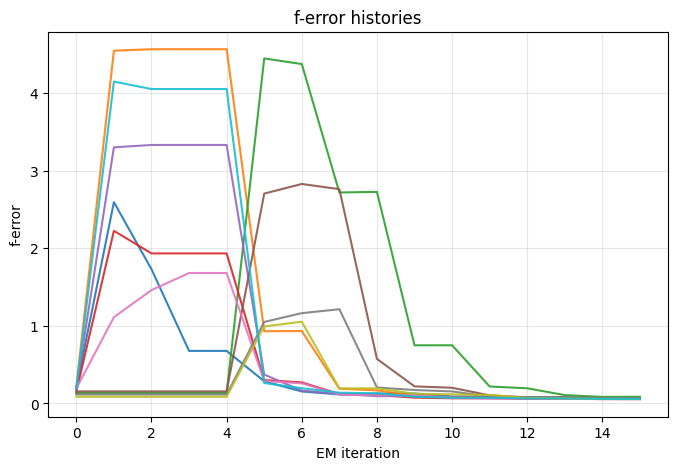


Run 0:
final_f: [0.0078 0.0243 0.0146 0.0324 0.0763 0.     0.0362 0.0117 0.     0.0035]
true_f:  [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.     0.     0.    ]

Run 1:
final_f: [0.0073 0.0251 0.0129 0.0315 0.0756 0.001  0.0341 0.0092 0.     0.004 ]
true_f:  [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.     0.     0.    ]

Run 2:
final_f: [0.0077 0.0314 0.0202 0.0412 0.0903 0.0014 0.0491 0.0202 0.0001 0.0043]
true_f:  [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.     0.     0.    ]

Run 3:
final_f: [0.0052 0.0246 0.0149 0.0314 0.0694 0.     0.0348 0.0117 0.     0.0029]
true_f:  [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.     0.     0.    ]

Run 4:
final_f: [0.0074 0.024  0.0126 0.0304 0.0733 0.0019 0.0322 0.0096 0.     0.0029]
true_f:  [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.     0.     0.    ]

Run 5:
final_f: [0.008  0.026  0.0155 0.0343 0.0793 0.0007 0.0382 0.0132 0.     0.0038]
true_f:  [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.

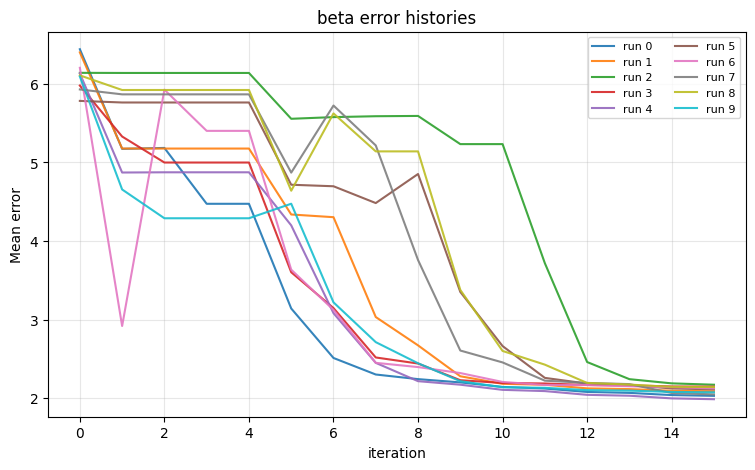

   run_index  initial_lse  final_lse  relative_improvement  spearman_f  \
0          0  4435.945827  31.016053              0.993008    0.821065   
1          1  5373.543250  30.963864              0.994238    0.821065   
2          2  9757.353114  31.970010              0.996723    0.743484   
3          3  9516.432906  30.505713              0.996794    0.823565   
4          4  3926.301257  30.993996              0.992106    0.821065   
5          5  7445.824530  31.523169              0.995766    0.821065   
6          6  9255.458694  30.436220              0.996712    0.821065   
7          7  5122.413483  30.753015              0.993996    0.745748   
8          8  5360.294891  30.605146              0.994290    0.823565   
9          9  6911.259996  30.527942              0.995583    0.823565   

   kendall_f  pearson_f  pct_zeros_initial_f  pct_zeros_final_f  \
0   0.629941   0.936483                  0.0               10.0   
1   0.629941   0.938715                  0.0       

In [10]:

best_em = results[best_idx]["model"]

plot_all_lse_histories(results)
plot_multi_init_errors(results, f_true=f, s_true=np.ones(n_biomarkers), scalar_K_true=1.0)
plot_f_error_histories_normalized(results, f_true=f)
plot_f_error_histories_raw(results, f_true=f)
print_final_f_comparison(results, f_true=f)
plot_beta_error_histories_all_runs(results, df, patients=X, normalize=False)



summary_df = summarize_multi_init_results(results, f_true=f)
print(summary_df.head(10))
